# Insurance Risk Advisor — Week 3: LLM Integration & Coverage Recommendations
**Project:** AI-Powered Insurance Policy Advisor & Risk Explainer  
**Author:** Shubham Maheshwari  
**LLM:** Groq (free) — llama-3.1-70b  
**Input:** `insurance_risk_model.pkl`, `label_encoders.pkl`, `features.json`

---
## Notebook Structure
1. Setup & Load Model Artifacts
2. Groq API Setup & Connection Test
3. Prompt Engineering — Risk Explanation
4. Prompt Engineering — Coverage Recommendation
5. Full AI Advisor Pipeline (ML + LLM combined)
6. Batch Testing — 5 Different Customer Profiles
7. Save Final Pipeline as advisor.py

## 1. Setup & Load Model Artifacts

In [18]:
# Install if needed:
!pip install groq python-dotenv joblib shap xgboost

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from datetime import datetime
from dotenv import load_dotenv
from groq import Groq
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')

# Load .env file — must be in same folder as this notebook
load_dotenv()

print('Libraries loaded.')
print(f'Groq library version: {__import__("groq").__version__}')

Libraries loaded.
Groq library version: 1.2.0



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# --- Load all artifacts saved in Week 2 ---
# All files are in the same folder as this notebook

model          = joblib.load('insurance_risk_model.pkl')
label_encoders = joblib.load('label_encoders.pkl')

with open('features.json') as f:
    FEATURES = json.load(f)

with open('model_metrics.json') as f:
    metrics = json.load(f)

print(f'Model loaded:    {type(model).__name__}')
print(f'Features loaded: {len(FEATURES)} features')
print(f'Model R²:        {metrics["r2_log_scale"]}')
print(f'Model MAE:       ${metrics["mae_dollars"]:,}')

Model loaded:    XGBRegressor
Features loaded: 16 features
Model R²:        0.8615
Model MAE:       $1,932.28


In [20]:
# --- Rellama-3.3-70b-versatileine helper functions from Week 2 ---
# These must be identical to Week 2 or predictions will be wrong

def engineer_features(df):
    df = df.copy()
    def bmi_category(bmi):
        if bmi < 18.5:  return 'Underweight'
        elif bmi < 25:  return 'Normal'
        elif bmi < 30:  return 'Overweight'
        elif bmi < 35:  return 'Obese'
        else:           return 'Severely_Obese'
    df['bmi_category']    = df['bmi'].apply(bmi_category)
    df['age_group']       = pd.cut(df['age'], bins=[0,25,35,45,55,100],
                                   labels=['18-25','26-35','36-45','46-55','55+']).astype(str)
    df['is_smoker']       = (df['smoker'] == 'yes').astype(int)
    df['is_obese']        = (df['bmi'] >= 30).astype(int)
    df['smoker_obese']    = df['is_smoker'] * df['is_obese']
    df['smoker_age_risk'] = df['is_smoker'] * (df['age'] >= 40).astype(int)
    df['obese_age_risk']  = df['is_obese']  * (df['age'] >= 40).astype(int)
    df['triple_risk']     = ((df['smoker']=='yes') & (df['bmi']>=30) & (df['age']>=40)).astype(int)
    df['family_size']     = df['children'] + 1
    df['bmi_age']         = df['bmi'] * df['age'] / 1000
    df['bmi_smoker']      = df['bmi'] * df['is_smoker']
    df['is_high_risk']    = 0
    return df


def get_ml_prediction(age, sex, bmi, children, smoker, region):
    """Run XGBoost model + SHAP for one customer. Returns structured dict."""
    raw = pd.DataFrame([{
        'age': age, 'sex': sex, 'bmi': bmi, 'children': children,
        'smoker': smoker, 'region': region,
        'charges': 0, 'risk_segment': 'UNKNOWN', 'log_charges': 0
    }])
    raw = engineer_features(raw)
    X_input = raw[FEATURES].copy()
    for col, le in label_encoders.items():
        X_input[col] = le.transform(X_input[col].astype(str))

    log_pred         = model.predict(X_input)[0]
    predicted_charge = float(np.expm1(log_pred))
    segment = ('HIGH' if predicted_charge > 25000 else
               'MEDIUM' if predicted_charge > 10000 else 'LOW')

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_input)[0]
    shap_df   = pd.DataFrame({'feature': FEATURES, 'shap_value': shap_vals})
    shap_df['direction'] = shap_df['shap_value'].apply(lambda x: 'increases' if x > 0 else 'decreases')
    shap_df['abs_shap']  = shap_df['shap_value'].abs()
    top_factors = shap_df.nlargest(4, 'abs_shap').to_dict('records')

    return {
        'predicted_charge': round(predicted_charge, 2),
        'risk_segment':     segment,
        'top_factors':      top_factors,
        'input': {
            'age': age, 'sex': sex, 'bmi': round(bmi, 1),
            'children': children, 'smoker': smoker, 'region': region
        }
    }

# Quick test
test = get_ml_prediction(45, 'male', 33, 2, 'yes', 'southeast')
print(f'Model working: ${test["predicted_charge"]:,.2f} — {test["risk_segment"]} RISK')

Model working: $41,583.46 — HIGH RISK


## 2. Groq API Setup & Connection Test
Groq is **completely free** — no credit card, no limits for this project.
Your `.env` file in this folder should contain: `GROQ_API_KEY=gsk_...`

In [21]:
# --- Check .env is loading correctly ---
key = os.getenv('GROQ_API_KEY')

if key:
    print(f'API key found: {key[:8]}...{key[-4:]}')
else:
    print('KEY NOT FOUND — check these:')
    print(f'  Current folder: {os.getcwd()}')
    print(f'  Files here: {os.listdir(".")}')
    print('  Make sure .env is in the same folder as this notebook')

API key found: gsk_8GAU...u2uH


In [22]:
# --- Initialize Groq client ---
client = Groq(api_key=os.getenv('GROQ_API_KEY'))

# Connection test
test_response = client.chat.completions.create(
    model='llama-3.1-8b-instant',
    messages=[{'role': 'user', 'content': 'Say exactly: Groq connected successfully.'}],
    max_tokens=20
)
print(test_response.choices[0].message.content)
print(f'Model used: {test_response.model}')
print(f'Tokens used: {test_response.usage.total_tokens}')
print(f'Cost: $0.00 (Groq free tier)')

Groq connected successfully.
Model used: llama-3.1-8b-instant
Tokens used: 49
Cost: $0.00 (Groq free tier)


## 3. Prompt Engineering — Risk Explanation
We use **two separate prompts** — one for explaining the risk, one for recommending coverage. Keeping them separate gives cleaner, more focused outputs from the LLM.

We use `llama-3.3-70b-versatile` here — smarter model for the actual explanations.

In [23]:
# --- System prompt for risk explanation ---
SYSTEM_PROMPT = """
You are an AI insurance advisor for a US insurance company.
Your job is to explain insurance risk assessments to customers in plain, empathetic English.

Rules:
- Write for a general audience — no jargon, no medical terms
- Be factual and clear, never alarming or judgmental
- Always explain WHY the risk is what it is using the provided factors
- Always give 2-3 actionable steps the customer can take to lower their premium
- Keep the explanation under 150 words
- Use a warm, professional tone — like a trusted financial advisor
- Never mention specific dollar amounts
- Structure your response with these exact sections:
  RISK SUMMARY: (1-2 sentences)
  KEY FACTORS: (bullet list of top 2-3 drivers)
  WHAT YOU CAN DO: (2-3 actionable recommendations)
"""

# Human-readable names for SHAP features
FACTOR_LABELS = {
    'is_smoker':       'smoking status',
    'bmi_smoker':      'combination of smoking and body weight',
    'age':             'age',
    'bmi':             'body mass index (BMI)',
    'bmi_age':         'age combined with body weight',
    'triple_risk':     'combination of smoking, obesity, and age over 40',
    'smoker_obese':    'smoking combined with obesity',
    'smoker_age_risk': 'smoking combined with being over 40',
    'obese_age_risk':  'obesity combined with being over 40',
    'children':        'number of dependents',
    'family_size':     'family size',
    'region':          'geographic region',
    'sex':             'gender',
    'age_group':       'age group',
    'bmi_category':    'BMI category',
    'is_obese':        'obesity status'
}

print('Prompts defined.')

Prompts defined.


In [24]:
def build_explanation_prompt(ml_result):
    """Converts ML output into a clear natural language prompt for the LLM."""
    inp     = ml_result['input']
    factors = ml_result['top_factors']

    bmi_label = ('underweight' if inp['bmi'] < 18.5 else
                 'healthy weight' if inp['bmi'] < 25 else
                 'overweight' if inp['bmi'] < 30 else
                 'obese' if inp['bmi'] < 35 else 'severely obese')

    factor_lines = '\n'.join([
        f"  - {FACTOR_LABELS.get(f['feature'], f['feature'])} ({f['direction']} expected costs)"
        for f in factors[:3]
    ])

    return f"""Customer profile:
- Age: {inp['age']} years old
- Sex: {inp['sex']}
- BMI: {inp['bmi']} ({bmi_label})
- Children/dependents: {inp['children']}
- Smoking status: {'a smoker' if inp['smoker'] == 'yes' else 'a non-smoker'}
- Region: {inp['region']} United States
- Risk assessment result: {ml_result['risk_segment']} RISK

Top factors driving this risk assessment:
{factor_lines}

Please explain this risk assessment to the customer."""


def get_risk_explanation(ml_result):
    """Call Groq LLM to explain the risk in plain English."""
    response = client.chat.completions.create(
        model='llama-3.3-70b-versatile',      # smarter model for explanations
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': build_explanation_prompt(ml_result)}
        ],
        max_tokens=400,
        temperature=0.4
    )
    return response.choices[0].message.content


# --- Test: HIGH RISK customer ---
print('Testing HIGH RISK explanation...')
print('='*60)
high_risk = get_ml_prediction(55, 'male', 36, 1, 'yes', 'southeast')
explanation_high = get_risk_explanation(high_risk)
print(f'Customer: 55yo male | BMI 36 | smoker | southeast')
print(f'Predicted: ${high_risk["predicted_charge"]:,.2f} | Risk: {high_risk["risk_segment"]}')
print('\n--- LLM Explanation ---')
print(explanation_high)

Testing HIGH RISK explanation...
Customer: 55yo male | BMI 36 | smoker | southeast
Predicted: $44,764.89 | Risk: HIGH

--- LLM Explanation ---
RISK SUMMARY: 
Your risk assessment result is HIGH RISK, which means you may face higher insurance premiums. This is because certain factors in your profile increase the likelihood of health issues, leading to higher expected costs.

KEY FACTORS: 
* Smoking status, which increases expected costs
* Combination of smoking and high body weight, which further increases expected costs
* Age, which also contributes to higher expected costs

WHAT YOU CAN DO: 
Consider quitting smoking to significantly lower your risk, as well as starting a weight loss program to improve your overall health. You can also consult with your doctor to discuss healthy lifestyle changes and create a plan to achieve them.


In [25]:
# --- Test: LOW RISK customer ---
print('Testing LOW RISK explanation...')
print('='*60)
low_risk = get_ml_prediction(28, 'female', 23, 0, 'no', 'northwest')
explanation_low = get_risk_explanation(low_risk)
print(f'Customer: 28yo female | BMI 23 | non-smoker | northwest')
print(f'Predicted: ${low_risk["predicted_charge"]:,.2f} | Risk: {low_risk["risk_segment"]}')
print('\n--- LLM Explanation ---')
print(explanation_low)

Testing LOW RISK explanation...
Customer: 28yo female | BMI 23 | non-smoker | northwest
Predicted: $4,769.26 | Risk: LOW

--- LLM Explanation ---
RISK SUMMARY: 
Your risk assessment result is LOW RISK, which is great news. This means you're likely to have lower insurance costs due to your overall healthy profile.

KEY FACTORS: 
* Your age, as younger individuals tend to have lower expected costs
* Your non-smoking status, which significantly decreases expected costs
* The combination of your healthy weight and non-smoking status, which further reduces expected costs

WHAT YOU CAN DO: 
Maintain your healthy weight through a balanced diet and regular exercise, consider participating in wellness programs offered by your employer or insurance provider, and continue to avoid smoking to keep your costs low.


## 4. Prompt Engineering — Coverage Recommendation

In [27]:
COVERAGE_SYSTEM_PROMPT = """
You are a US health and life insurance coverage advisor.
Based on a customer's risk profile, recommend the most appropriate insurance coverage.

Available plan types:
- HMO: lower cost, requires referrals, good for healthy low-risk customers
- PPO: more flexibility, higher cost, good for those needing specialist access
- HDHP + HSA: high deductible + health savings account, good for young healthy people
- Comprehensive Plan: full coverage including dental, vision, critical illness — for high risk
- Term Life Insurance: important if customer has dependents

Rules:
- Recommend 2 plan types maximum
- Explain in one sentence why each plan fits this customer
- Keep total response under 100 words
- Use this exact format:
  RECOMMENDED PLANS:
  1. [Plan name]: [why in one sentence]
  2. [Plan name]: [why in one sentence]
  COVERAGE NOTE: [one important thing to be aware of]
"""


def get_coverage_recommendation(ml_result):
    """Get insurance plan recommendations for a customer."""
    inp = ml_result['input']
    avg_charge = 13270  # dataset average from Week 1

    prompt = f"""Customer: {inp['age']}yo {inp['sex']}, BMI {inp['bmi']}, \
{'smoker' if inp['smoker']=='yes' else 'non-smoker'}, \
{inp['children']} dependents, {inp['region']} US.
Risk level: {ml_result['risk_segment']} RISK.
Premium level: {'above average' if ml_result['predicted_charge'] > avg_charge else 'below average'}.

What coverage do you recommend?"""

    response = client.chat.completions.create(
        model='llama-3.3-70b-versatile',
        messages=[
            {'role': 'system', 'content': COVERAGE_SYSTEM_PROMPT},
            {'role': 'user',   'content': prompt}
        ],
        max_tokens=250,
        temperature=0.3
    )
    return response.choices[0].message.content


print('--- Coverage: HIGH RISK ---')
print(get_coverage_recommendation(high_risk))
print('\n--- Coverage: LOW RISK ---')
print(get_coverage_recommendation(low_risk))

--- Coverage: HIGH RISK ---
RECOMMENDED PLANS:
1. Comprehensive Plan: This plan fits due to the customer's high risk profile and need for full coverage.
2. Term Life Insurance: This plan is suitable as the customer has a dependent and a high risk profile.
COVERAGE NOTE: Regular health check-ups are crucial to manage chronic conditions.

--- Coverage: LOW RISK ---
RECOMMENDED PLANS:
1. **HDHP + HSA**: Suitable for young, healthy individuals with low medical expenses.
2. **HMO**: Fits her low-risk profile and budget, providing basic care at a lower cost.
COVERAGE NOTE: Regular health check-ups are still important to maintain overall well-being.


## 5. Full AI Advisor Pipeline
One function that chains everything: ML → SHAP → Risk Explanation → Coverage Recommendation.

In [28]:
def run_full_advisor(age, sex, bmi, children, smoker, region, verbose=True):
    """
    Complete insurance advisor pipeline.
    
    Step 1 — ML model predicts risk score and annual charge
    Step 2 — SHAP identifies which factors drive the prediction
    Step 3 — LLM explains the risk in plain English
    Step 4 — LLM recommends the right coverage type
    
    Returns: complete advisory report as a dict
    """
    if verbose:
        print(f'Running advisor: {age}yo {sex} | BMI {bmi} | {smoker} | {children} children | {region}')

    # Steps 1 & 2
    ml_result = get_ml_prediction(age, sex, bmi, children, smoker, region)
    if verbose:
        print(f'  ML done → ${ml_result["predicted_charge"]:,.0f} | {ml_result["risk_segment"]} RISK')

    # Step 3
    explanation = get_risk_explanation(ml_result)
    if verbose:
        print(f'  LLM explanation done.')

    # Step 4
    coverage = get_coverage_recommendation(ml_result)
    if verbose:
        print(f'  Coverage recommendation done.')

    report = {
        'timestamp':               datetime.now().isoformat(),
        'customer_input':          ml_result['input'],
        'predicted_annual_charge': ml_result['predicted_charge'],
        'risk_segment':            ml_result['risk_segment'],
        'top_risk_factors': [
            {'feature':   f['feature'],
             'direction': f['direction'],
             'impact':    round(f['shap_value'], 4)}
            for f in ml_result['top_factors']
        ],
        'risk_explanation':        explanation,
        'coverage_recommendation': coverage
    }

    if verbose:
        print('\n' + '='*65)
        print(' INSURANCE RISK ADVISOR — FULL REPORT')
        print('='*65)
        print(f"  Customer:  {age}yo {sex} | BMI {bmi} | {'Smoker' if smoker=='yes' else 'Non-smoker'} | {children} children")
        print(f"  Region:    {region}")
        print(f"  Predicted Annual Premium: ${ml_result['predicted_charge']:,.2f}")
        print(f"  Risk Level: {ml_result['risk_segment']} RISK")
        print(f"\n  Top Risk Factors:")
        for f in report['top_risk_factors']:
            print(f"    • {f['feature']:<20} {f['direction']} risk  (SHAP: {f['impact']:+.3f})")
        print(f"\n--- RISK EXPLANATION ---")
        print(explanation)
        print(f"\n--- COVERAGE RECOMMENDATION ---")
        print(coverage)
        print('='*65)

    return report


# Full test run
report = run_full_advisor(
    age=42, sex='female', bmi=31, children=3, smoker='yes', region='southeast'
)

Running advisor: 42yo female | BMI 31 | yes | 3 children | southeast
  ML done → $40,753 | HIGH RISK
  LLM explanation done.
  Coverage recommendation done.

 INSURANCE RISK ADVISOR — FULL REPORT
  Customer:  42yo female | BMI 31 | Smoker | 3 children
  Region:    southeast
  Predicted Annual Premium: $40,753.02
  Risk Level: HIGH RISK

  Top Risk Factors:
    • is_smoker            increases risk  (SHAP: +0.765)
    • bmi_smoker           increases risk  (SHAP: +0.464)
    • bmi                  increases risk  (SHAP: +0.095)
    • children             increases risk  (SHAP: +0.050)

--- RISK EXPLANATION ---
RISK SUMMARY: 
Your risk assessment result is HIGH RISK, which means that your insurance premium may be higher due to certain factors. This is because some aspects of your lifestyle and health may increase the likelihood of health issues.

KEY FACTORS: 
* Your smoking status, which can lead to various health problems
* The combination of smoking and a higher body weight, which can

## 6. Batch Testing — 5 Customer Profiles
Tests the full pipeline across the full risk spectrum.

In [29]:
TEST_PROFILES = [
    {'age': 62, 'sex': 'male',   'bmi': 38.0, 'children': 0, 'smoker': 'yes', 'region': 'southeast', 'label': 'Senior smoker — max risk'},
    {'age': 45, 'sex': 'female', 'bmi': 32.5, 'children': 2, 'smoker': 'yes', 'region': 'northeast', 'label': 'Middle-aged smoker with family'},
    {'age': 38, 'sex': 'male',   'bmi': 28.0, 'children': 3, 'smoker': 'no',  'region': 'southeast', 'label': 'Overweight with family — medium'},
    {'age': 25, 'sex': 'female', 'bmi': 24.0, 'children': 0, 'smoker': 'no',  'region': 'northwest', 'label': 'Young healthy — lowest risk'},
    {'age': 50, 'sex': 'male',   'bmi': 30.5, 'children': 1, 'smoker': 'no',  'region': 'southwest', 'label': 'Borderline — age + mild obesity'},
]

batch_results = []

for profile in TEST_PROFILES:
    label = profile.pop('label')
    print(f'\n>>> {label}')
    report = run_full_advisor(**profile, verbose=False)
    print(f"  Predicted: ${report['predicted_annual_charge']:,.0f}  |  Risk: {report['risk_segment']}")
    print(f"  Top factor: {report['top_risk_factors'][0]['feature']} ({report['top_risk_factors'][0]['direction']})")
    batch_results.append({'label': label, **report})
    profile['label'] = label

print('\nAll 5 profiles done.')


>>> Senior smoker — max risk
  Predicted: $45,490  |  Risk: HIGH
  Top factor: is_smoker (increases)

>>> Middle-aged smoker with family
  Predicted: $41,243  |  Risk: HIGH
  Top factor: is_smoker (increases)

>>> Overweight with family — medium
  Predicted: $6,739  |  Risk: LOW
  Top factor: is_smoker (decreases)

>>> Young healthy — lowest risk
  Predicted: $3,443  |  Risk: LOW
  Top factor: age (decreases)

>>> Borderline — age + mild obesity
  Predicted: $9,523  |  Risk: LOW
  Top factor: age (increases)

All 5 profiles done.


Batch Results Summary:
                        Profile  Age Smoker  BMI Predicted ($) Risk Top Factor
       Senior smoker — max risk   62    yes 38.0       $45,490 HIGH  is_smoker
 Middle-aged smoker with family   45    yes 32.5       $41,243 HIGH  is_smoker
Overweight with family — medium   38     no 28.0        $6,739  LOW  is_smoker
    Young healthy — lowest risk   25     no 24.0        $3,443  LOW        age
Borderline — age + mild obesity   50     no 30.5        $9,523  LOW        age


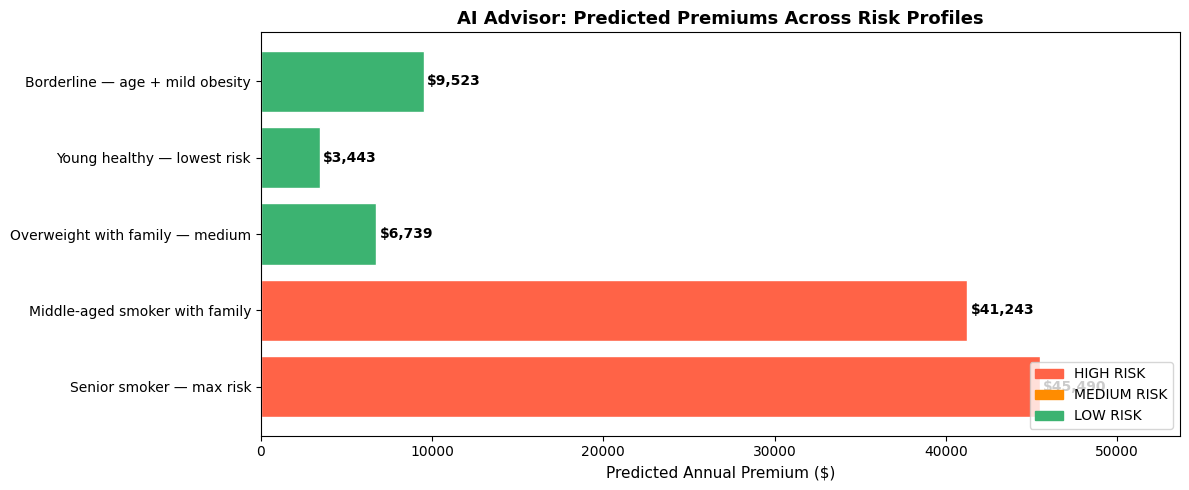

In [30]:
# --- Summary table ---
summary = pd.DataFrame([{
    'Profile':       r['label'],
    'Age':           r['customer_input']['age'],
    'Smoker':        r['customer_input']['smoker'],
    'BMI':           r['customer_input']['bmi'],
    'Predicted ($)': f"${r['predicted_annual_charge']:,.0f}",
    'Risk':          r['risk_segment'],
    'Top Factor':    r['top_risk_factors'][0]['feature']
} for r in batch_results])

print('Batch Results Summary:')
print(summary.to_string(index=False))

# Bar chart
charges = [r['predicted_annual_charge'] for r in batch_results]
labels  = [r['label'] for r in batch_results]
colors  = ['tomato' if r['risk_segment']=='HIGH' else
           'darkorange' if r['risk_segment']=='MEDIUM' else
           'mediumseagreen' for r in batch_results]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(labels, charges, color=colors, edgecolor='white')
ax.set_xlabel('Predicted Annual Premium ($)', fontsize=11)
ax.set_title('AI Advisor: Predicted Premiums Across Risk Profiles', fontweight='bold', fontsize=13)
for bar, val in zip(bars, charges):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontweight='bold')
ax.set_xlim(0, max(charges) * 1.18)
legend_patches = [
    mpatches.Patch(color='tomato',         label='HIGH RISK'),
    mpatches.Patch(color='darkorange',     label='MEDIUM RISK'),
    mpatches.Patch(color='mediumseagreen', label='LOW RISK')
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.savefig('batch_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Final Pipeline as advisor.py
This file is what the Streamlit app imports in Week 4. All logic lives here.

In [31]:
advisor_code = '''"""
advisor.py — Core AI Insurance Advisor Pipeline
Author: Shubham Maheshwari

Usage:
    from advisor import run_full_advisor
    report = run_full_advisor(age=35, sex="male", bmi=28, children=1, smoker="no", region="northeast")
"""

import os, json, joblib
import numpy as np
import pandas as pd
from datetime import datetime
from groq import Groq
import shap
from dotenv import load_dotenv

load_dotenv()
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

_model          = joblib.load("insurance_risk_model.pkl")
_label_encoders = joblib.load("label_encoders.pkl")
_explainer      = shap.TreeExplainer(_model)
with open("features.json") as f:
    _FEATURES = json.load(f)

SYSTEM_PROMPT = """
You are an AI insurance advisor. Explain risk assessments in plain, empathetic English.
Rules: no jargon, warm tone, under 150 words, never mention dollar amounts.
Format:
  RISK SUMMARY: (1-2 sentences)
  KEY FACTORS: (2-3 bullets)
  WHAT YOU CAN DO: (2-3 recommendations)
"""

COVERAGE_PROMPT = """
You are a US insurance coverage advisor. Recommend 2 plans max, under 100 words.
Plans: HMO, PPO, HDHP+HSA, Comprehensive, Term Life.
Format:
  RECOMMENDED PLANS:
  1. [Plan]: [why]
  2. [Plan]: [why]
  COVERAGE NOTE: [one key consideration]
"""

FACTOR_LABELS = {
    "is_smoker": "smoking status", "bmi_smoker": "smoking and body weight combined",
    "age": "age", "bmi": "body mass index", "bmi_age": "age and weight combined",
    "triple_risk": "smoking + obesity + age over 40", "smoker_obese": "smoking and obesity",
    "smoker_age_risk": "smoking over age 40", "children": "number of dependents",
    "region": "geographic region", "is_obese": "obesity status"
}

def _engineer(df):
    df = df.copy()
    def bmi_cat(b):
        if b<18.5: return "Underweight"
        elif b<25: return "Normal"
        elif b<30: return "Overweight"
        elif b<35: return "Obese"
        else:      return "Severely_Obese"
    df["bmi_category"]    = df["bmi"].apply(bmi_cat)
    df["age_group"]       = pd.cut(df["age"], bins=[0,25,35,45,55,100],
                                   labels=["18-25","26-35","36-45","46-55","55+"]).astype(str)
    df["is_smoker"]       = (df["smoker"]=="yes").astype(int)
    df["is_obese"]        = (df["bmi"]>=30).astype(int)
    df["smoker_obese"]    = df["is_smoker"] * df["is_obese"]
    df["smoker_age_risk"] = df["is_smoker"] * (df["age"]>=40).astype(int)
    df["obese_age_risk"]  = df["is_obese"]  * (df["age"]>=40).astype(int)
    df["triple_risk"]     = ((df["smoker"]=="yes")&(df["bmi"]>=30)&(df["age"]>=40)).astype(int)
    df["family_size"]     = df["children"] + 1
    df["bmi_age"]         = df["bmi"] * df["age"] / 1000
    df["bmi_smoker"]      = df["bmi"] * df["is_smoker"]
    df["is_high_risk"]    = 0
    return df

def run_full_advisor(age, sex, bmi, children, smoker, region):
    # ML prediction
    raw = pd.DataFrame([{"age":age,"sex":sex,"bmi":bmi,"children":children,
                         "smoker":smoker,"region":region,
                         "charges":0,"risk_segment":"UNKNOWN","log_charges":0}])
    raw = _engineer(raw)
    X   = raw[_FEATURES].copy()
    for col, le in _label_encoders.items():
        X[col] = le.transform(X[col].astype(str))
    charge  = float(np.expm1(_model.predict(X)[0]))
    segment = "HIGH" if charge>25000 else ("MEDIUM" if charge>10000 else "LOW")

    # SHAP
    sv  = _explainer.shap_values(X)[0]
    sf  = pd.DataFrame({"feature":_FEATURES,"shap_value":sv})
    sf["direction"] = sf["shap_value"].apply(lambda x: "increases" if x>0 else "decreases")
    sf["abs"]       = sf["shap_value"].abs()
    factors = sf.nlargest(4,"abs").to_dict("records")

    bmi_label = ("underweight" if bmi<18.5 else "healthy weight" if bmi<25
                 else "overweight" if bmi<30 else "obese" if bmi<35 else "severely obese")
    factor_lines = "\\n".join(
        f"  - {FACTOR_LABELS.get(f[\'feature\'],f[\'feature\'])} ({f[\'direction\']} costs)"
        for f in factors[:3]
    )
    exp_prompt = (f"Customer: {age}yo {sex}, BMI {bmi} ({bmi_label}), "
                  f"{\'smoker\' if smoker==\'yes\' else \'non-smoker\'}, "
                  f"{children} children, {region} US.\\nRisk: {segment} RISK\\n"
                  f"Factors:\\n{factor_lines}")
    cov_prompt  = (f"Customer: {age}yo {sex}, BMI {bmi}, {smoker} smoker, "
                   f"{children} dependents, {region}, {segment} RISK.")

    explanation = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role":"system","content":SYSTEM_PROMPT},{"role":"user","content":exp_prompt}],
        max_tokens=400, temperature=0.4
    ).choices[0].message.content

    coverage = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role":"system","content":COVERAGE_PROMPT},{"role":"user","content":cov_prompt}],
        max_tokens=250, temperature=0.3
    ).choices[0].message.content

    return {
        "timestamp":               datetime.now().isoformat(),
        "customer_input":          {"age":age,"sex":sex,"bmi":round(bmi,1),
                                    "children":children,"smoker":smoker,"region":region},
        "predicted_annual_charge": round(charge, 2),
        "risk_segment":            segment,
        "top_risk_factors":        [{"feature":f["feature"],"direction":f["direction"],
                                     "impact":round(float(f["shap_value"]),4)} for f in factors],
        "risk_explanation":        explanation,
        "coverage_recommendation": coverage
    }
'''

with open('advisor.py', 'w') as f:
    f.write(advisor_code)

print('Saved: advisor.py')
print('This is your backend. Week 4 Streamlit app imports this file.')

Saved: advisor.py
This is your backend. Week 4 Streamlit app imports this file.


In [32]:
# --- Week 3 Summary ---
print('='*60)
print(' WEEK 3 COMPLETE')
print('='*60)
items = [
    ('Groq API connected',       'Free — llama-3.3-70b-versatile'),
    ('Risk explanation prompt',  'Structured: SUMMARY / FACTORS / ACTIONS'),
    ('Coverage recommendation',  'HMO / PPO / HDHP / Comprehensive'),
    ('Full pipeline function',   'run_full_advisor() — ML + SHAP + 2x LLM'),
    ('Batch test — 5 profiles',  'HIGH / MEDIUM / LOW all working'),
    ('advisor.py saved',         'Ready for Streamlit import in Week 4'),
]
for item, detail in items:
    print(f'  ✓ {item:<30} {detail}')
print()
print('  Files ready for Week 4:')
for f in ['advisor.py', 'insurance_risk_model.pkl', 'label_encoders.pkl', 'features.json', '.env']:
    print(f'    {f}')
print()
print('  NEXT: Week 4 — Streamlit app + deploy to Streamlit Cloud')
print('='*60)

 WEEK 3 COMPLETE
  ✓ Groq API connected             Free — llama-3.3-70b-versatile
  ✓ Risk explanation prompt        Structured: SUMMARY / FACTORS / ACTIONS
  ✓ Coverage recommendation        HMO / PPO / HDHP / Comprehensive
  ✓ Full pipeline function         run_full_advisor() — ML + SHAP + 2x LLM
  ✓ Batch test — 5 profiles        HIGH / MEDIUM / LOW all working
  ✓ advisor.py saved               Ready for Streamlit import in Week 4

  Files ready for Week 4:
    advisor.py
    insurance_risk_model.pkl
    label_encoders.pkl
    features.json
    .env

  NEXT: Week 4 — Streamlit app + deploy to Streamlit Cloud
